# Regression Analysis: Simplify complex data relationships



**The goal:** build a logistic regression model and evaluate the model.

## Imports and loading

In [142]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

from sklearn.model_selection import train_test_split as tts
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression as LR
from statsmodels.stats.multicomp import pairwise_tukeyhsd as hsd

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Load dataset
df = pd.read_csv("tiktok_dataset.csv")

### Explore data with EDA**

In [4]:
df.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [5]:
df.shape

(19382, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [7]:
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [11]:
# Check and drop missing value
df = df.dropna()
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


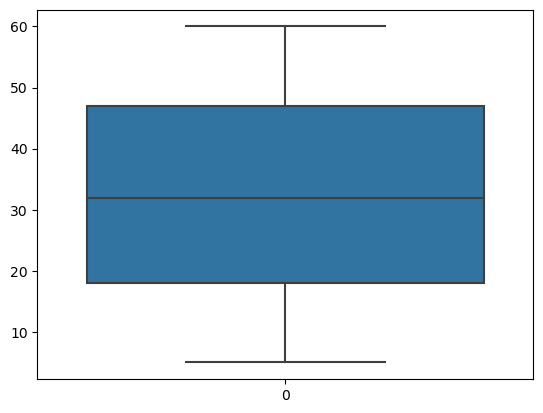

In [14]:
# Outlier in column of interest

#                                               video_duration_sec

sns.boxplot(df['video_duration_sec'])
plt.show()

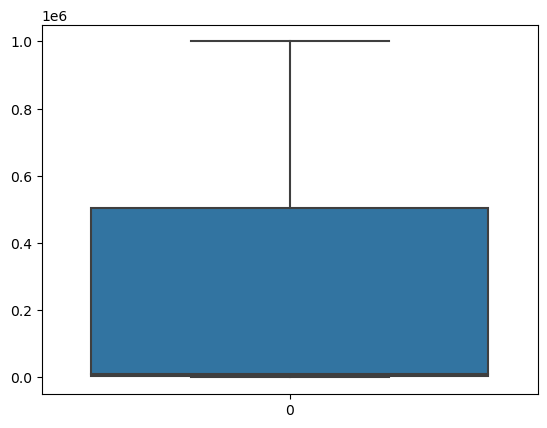

In [15]:
#                                           video_view_count

sns.boxplot(df['video_view_count'])
plt.show()

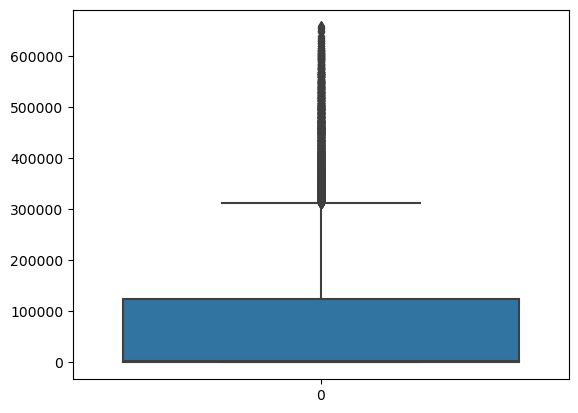

In [16]:
#                                                 `video_like_count`

sns.boxplot(df['video_like_count'])
plt.show()



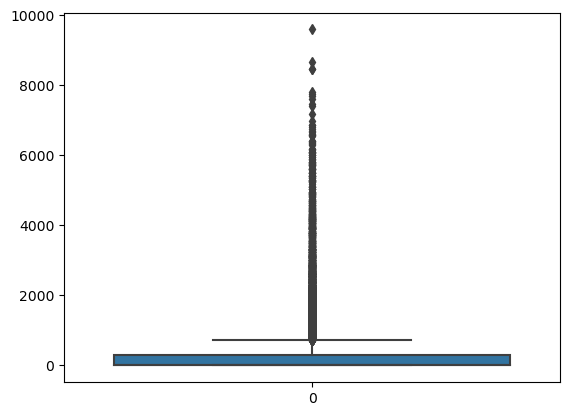

In [17]:
#                                                      `video_comment_count`

sns.boxplot(df['video_comment_count'])
plt.show()

In [18]:
# Handle outliers for video_like_count

Q1 = df['video_like_count'].quantile(0.25)
Q3 = Q1 = df['video_like_count'].quantile(0.75)

iqr = Q3 - Q1
Ulim = Q3 + 1.5 * iqr

df.loc[df['video_like_count'] > Ulim, 'video_like_count'] = Ulim

In [21]:
# Check class balance

df['verified_status'].value_counts(normalize=True)

verified_status
not verified    0.93712
verified        0.06288
Name: proportion, dtype: float64

In [28]:
# A 90-10 percent in class can be a problem, so I will resample to rebalance it. Using upsampling because the dataset is not to big

data_majority = df[df["verified_status"] == "not verified"]
data_minority = df[df["verified_status"] == "verified"]

# Upsample the minority class
from sklearn.utils import resample
data_minority_sampled = resample(data_minority, replace=True, n_samples=len(data_majority), random_state=0) 

# Recombine data
data_sampled = pd.concat([data_majority, data_minority_sampled]).reset_index(drop=True)

# Check new balance
data_sampled["verified_status"].value_counts()

verified_status
not verified    17884
verified        17884
Name: count, dtype: int64

# Some feature Engineering

In [51]:
# average `video_transcription_text` length for claims and the average `video_transcription_text` length for opinions

data_sampled.groupby('claim_status')['video_transcription_text'].apply(lambda x: x.str.len().mean())

claim_status
claim      95.200032
opinion    82.570643
Name: video_transcription_text, dtype: float64

In [39]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe

data_sampled['video_transcription_lenght'] = data_sampled['video_transcription_text']
data_sampled['video_transcription_lenght'] = data_sampled['video_transcription_lenght'].str.len()

# Check
data_sampled.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,video_transcription_lenght
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,125020.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


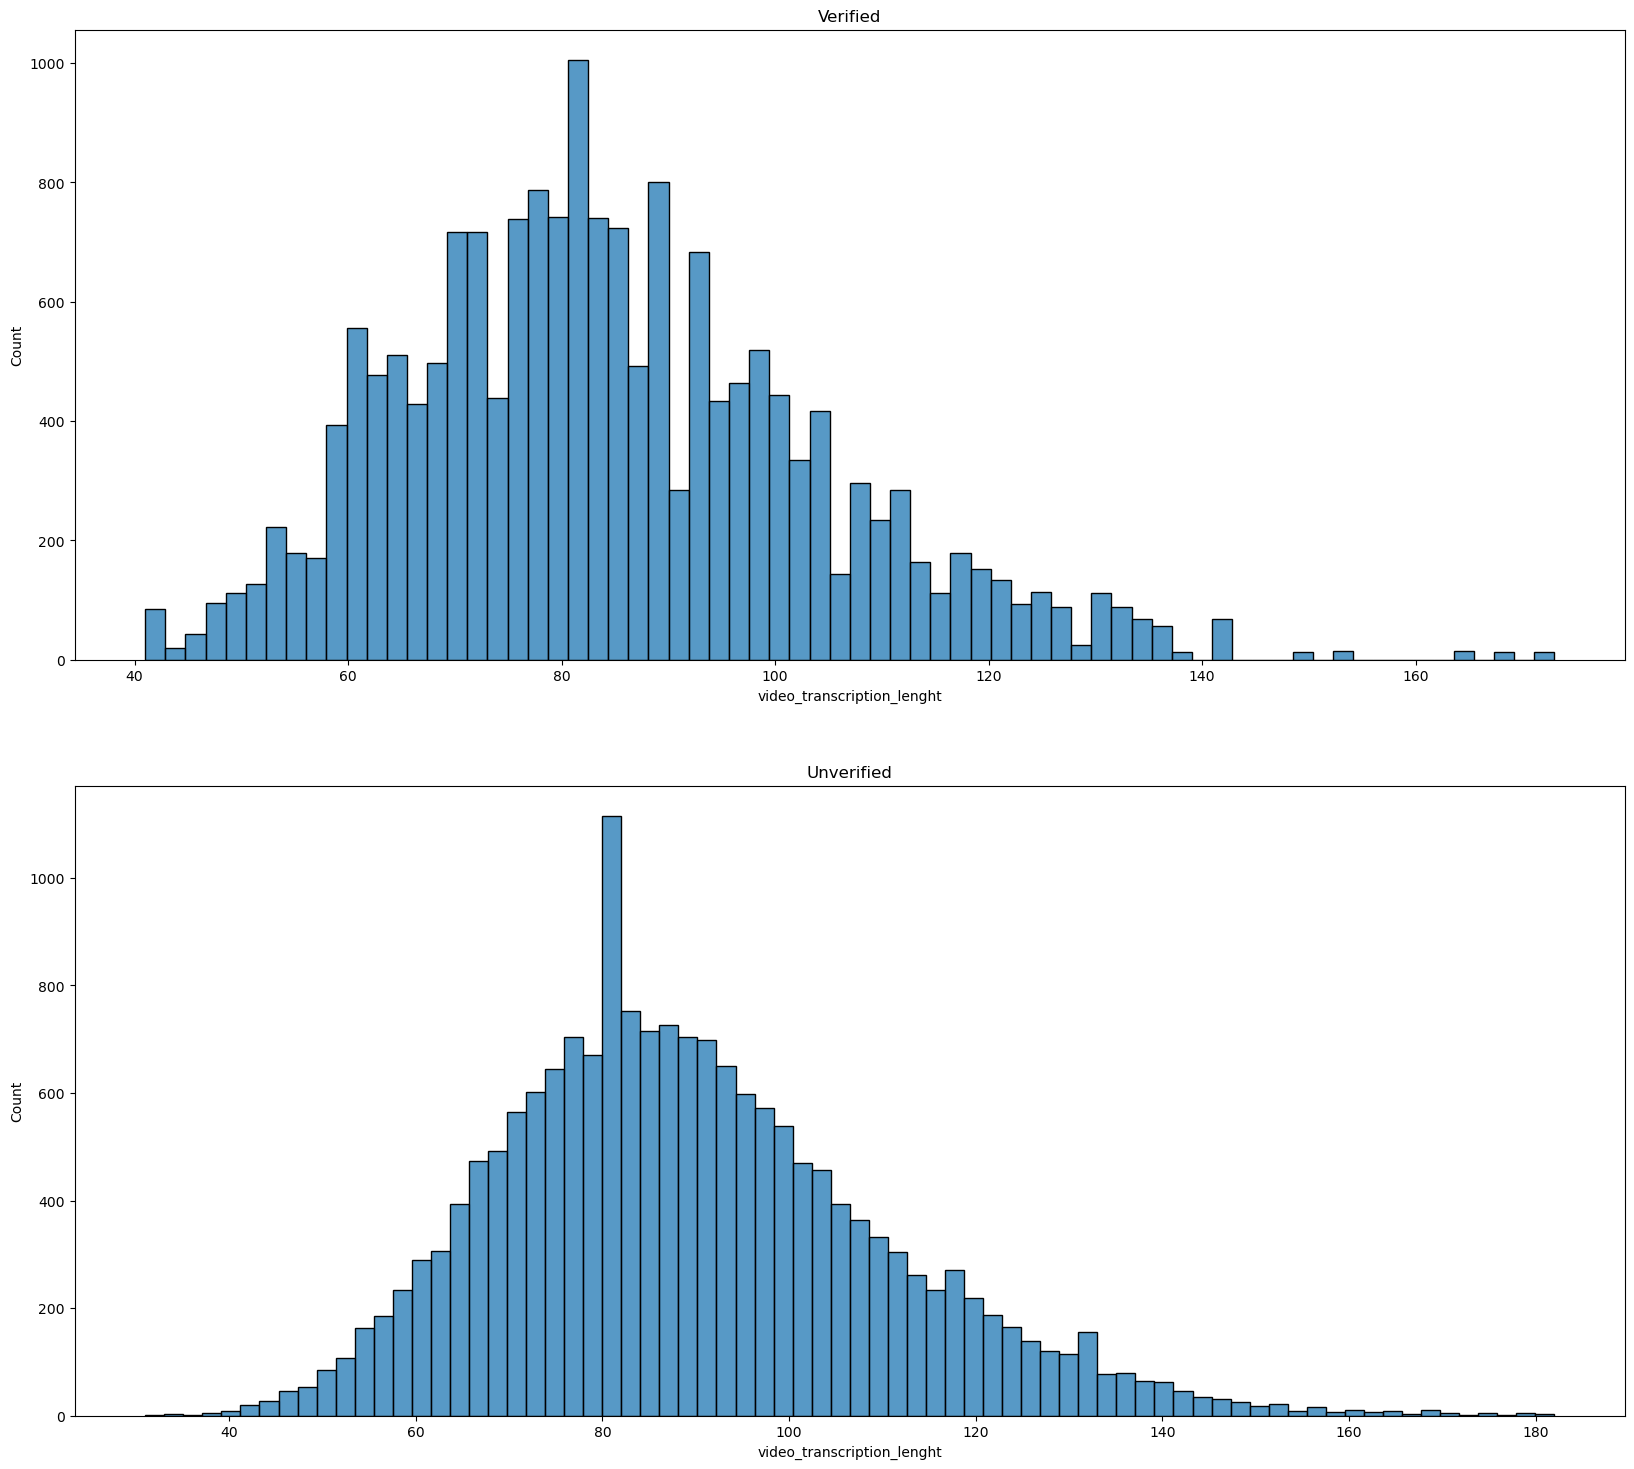

In [54]:
# Visualize the distribution of `video_transcription_text` length for the two verified_status


fig, (ax1, ax2) = plt.subplots(2,1,figsize=(20,18))
sns.histplot(data_sampled[data_sampled['verified_status'] == 'verified']['video_transcription_lenght'], ax=ax1)
ax1.set_title('Verified')
sns.histplot(data_sampled[data_sampled['verified_status'] == 'not verified']['video_transcription_lenght'], ax=ax2)
ax2.set_title('Unverified')       
fig.show()


### Examine correlations

In [56]:
# Correlation Matrix

data_sampled.corr(numeric_only=True)

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,video_transcription_lenght
#,1.000000,-0.000853,-0.011729,-0.697007,-0.715517,-0.504015,-0.487096,-0.413799,-0.193677
video_id,-0.000853,1.000000,0.011859,0.002554,0.001798,0.010515,0.008753,0.013983,-0.007083
video_duration_sec,-0.011729,0.011859,1.000000,0.013589,0.004201,0.002206,0.003989,-0.004586,-0.002981
video_view_count,-0.697007,0.002554,0.013589,1.000000,0.871606,0.711313,0.690048,0.583485,0.244693
video_like_count,-0.715517,0.001798,0.004201,0.871606,1.000000,0.746311,0.726478,0.616233,0.248770
video_share_count,-0.504015,0.010515,0.002206,0.711313,0.746311,1.000000,0.710117,0.620182,0.171651
video_download_count,-0.487096,0.008753,0.003989,0.690048,0.726478,0.710117,1.000000,0.857679,0.173396
video_comment_count,-0.413799,0.013983,-0.004586,0.583485,0.616233,0.620182,0.857679,1.000000,0.149750
video_transcription_lenght,-0.193677,-0.007083,-0.002981,0.244693,0.248770,0.171651,0.173396,0.149750,1.000000


Visualize a correlation heatmap of the data.

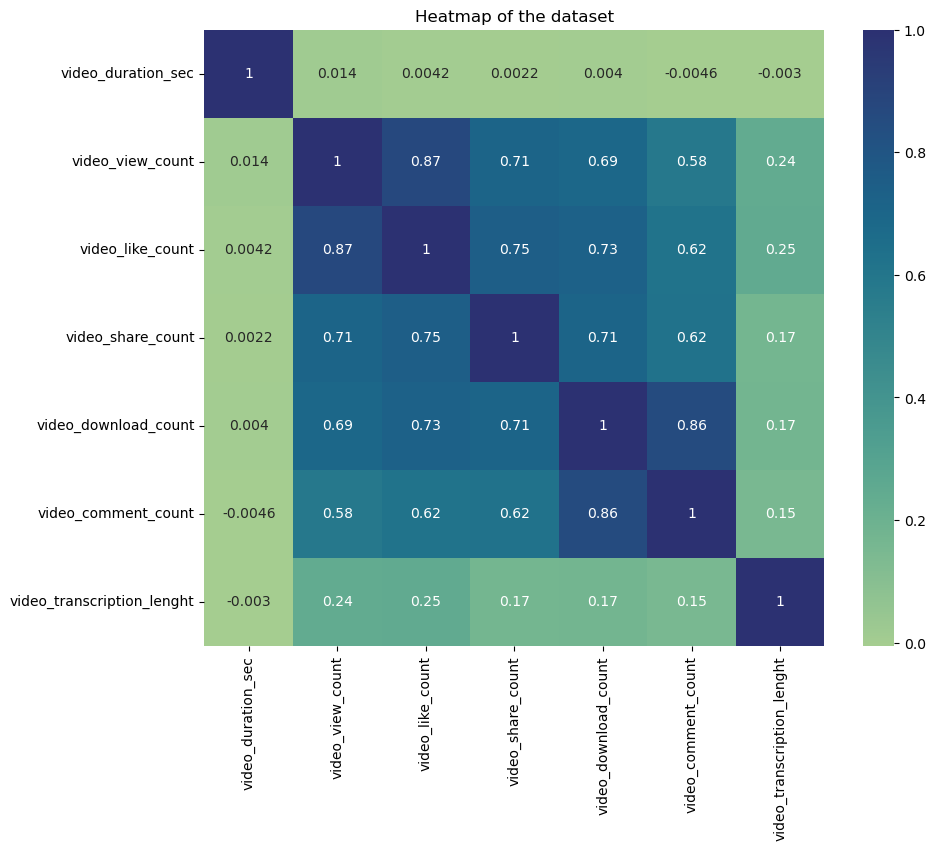

In [58]:
# Better visualization

plt.figure(figsize=(10, 8))
sns.heatmap(data_sampled[["video_duration_sec", "claim_status", "author_ban_status", "video_view_count", "video_like_count", "video_share_count", "video_download_count", "video_comment_count", "video_transcription_lenght"]].corr(numeric_only=True), annot=True, cmap="crest")
plt.title("Heatmap of the dataset")
plt.show()

### Time for the model

In [130]:
# Outcome variable

Y = data_sampled[['verified_status']]

# Features

X = data_sampled[["video_duration_sec", "claim_status", "author_ban_status", "video_view_count", "video_share_count", "video_download_count", "video_comment_count"]]

,verified_status
0,not verified
1,not verified
2,not verified
3,not verified
4,not verified
5,not verified
6,not verified
7,not verified
8,not verified
9,not verified


In [109]:
# Encode string column

#                                                        claim_status
X['claim_status'].unique()



array(['claim', 'opinion'], dtype=object)

In [110]:
#                                                        author_ban_status

X['author_ban_status'].unique()


array(['under review', 'active', 'banned'], dtype=object)

In [131]:
# Set the new encoded column

# author_ban_status
X.loc[X['author_ban_status'] == 'banned', 'author_ban_status'] = 0
X.loc[X['author_ban_status'] == 'under review', 'author_ban_status'] = 1
X.loc[X['author_ban_status'] == 'active', 'author_ban_status'] = 2

# claim_status
X.loc[X['claim_status'] == 'claim', 'claim_status'] = 0
X.loc[X['claim_status'] == 'opinion', 'claim_status'] = 1

# verified_status_encoded
Y['verified_status_encoded'] = 0
Y.loc[Y['verified_status'] == 'verified', 'verified_status_encoded'] = 1
Y = Y.drop(columns='verified_status')
Y.sample(20)

/tmp/ipykernel_61/264094071.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y['verified_status_encoded'] = 0


,verified_status_encoded
20392,1
6050,0
25972,1
3655,0
20556,1
9049,0
8772,0
13577,0
31102,1
24224,1


In [135]:
# SPLIT TRAIN AND TEST SET

X_train, X_test, y_train, y_test = tts(X, Y, test_size=0.25, random_state=0)
y_train

,verified_status_encoded
33058,1
20491,1
25583,1
18474,1
27312,1
...,...
20757,1
32103,1
30403,1
21243,1


In [137]:
# Construct a logistic regression model and fit it to the training set

Y_train = y_train['verified_status_encoded'] # dataframe for y return error so change object type

# Logistic Regression model fit
clf = LR(random_state=0).fit(X_train, Y_train)


### Results and evaluation

In [139]:
# Prediction on the test set

y_pred = clf.predict(X_test)
y_pred

array([1, 1, 0, ..., 1, 0, 1])

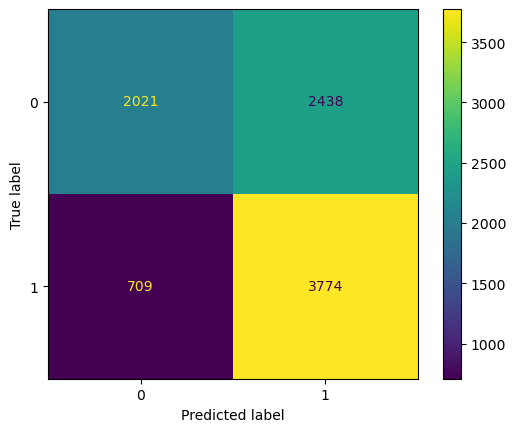

In [144]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

In [147]:
# Classification report

prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
acc = metrics.accuracy_score(y_test, y_pred)
print(metrics.classification_report(y_test, y_pred, target_names=['verified', 'not verified']))

              precision    recall  f1-score   support

    verified       0.74      0.45      0.56      4459
not verified       0.61      0.84      0.71      4483

    accuracy                           0.65      8942
   macro avg       0.67      0.65      0.63      8942
weighted avg       0.67      0.65      0.63      8942



In [148]:
# Model Coefficient

pd.DataFrame(data={"Feature Name":clf.feature_names_in_, "Model Coefficient":clf.coef_[0]})

,Feature Name,Model Coefficient
0,video_duration_sec,0.008483
1,claim_status,0.000377
2,author_ban_status,0.000606
3,video_view_count,-0.000002
4,video_share_count,0.000005
5,video_download_count,-0.000214
6,video_comment_count,0.000390
